In [18]:
### All domain plot
import xarray as xr
from scipy.io import loadmat
import pandas as pd
import cmocean as cm
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TwoSlopeNorm

In [36]:
## FUNCTIONS
## kml to struct
import re
from xml.etree import ElementTree as ET
import numpy as np

def kml2struct(kml_file):
    """
    Import a .kml file as a list of dictionary structures with fields:
    Geometry, Name, Description, Lon, Lat, and BoundingBox.
    """
    # Read the KML file
    try:
        with open(kml_file, 'r', encoding='utf-8') as file:
            txt = file.read()
    except Exception as e:
        raise FileNotFoundError(f"Unable to open file {kml_file}: {e}")

    # Regular expression to match Placemark tags
    expr = r"<Placemark.+?>.+?</Placemark>"
    object_strings = re.findall(expr, txt, re.DOTALL)
    
    kml_struct = []

    for obj_str in object_strings:
        # Extract Name
        name_match = re.search(r"<name.*?>(.*?)</name>", obj_str, re.DOTALL)
        name = name_match.group(1).strip() if name_match else "undefined"

        # Extract Description
        desc_match = re.search(r"<description.*?>(.*?)</description>", obj_str, re.DOTALL)
        desc = desc_match.group(1).strip() if desc_match else ""

        # Determine Geometry Type
        geometry = ""
        if "<Point" in obj_str:
            geometry = "Point"
        elif "<LineString" in obj_str:
            geometry = "Line"
        elif "<Polygon" in obj_str:
            geometry = "Polygon"

        # Extract Coordinates
        coord_match = re.search(r"<coordinates.*?>(.*?)</coordinates>", obj_str, re.DOTALL)
        if not coord_match:
            continue  # Skip if no coordinates are found
        coord_str = coord_match.group(1).strip()
        coord_list = np.array([list(map(float, coord.split(','))) for coord in coord_str.split()])

        # Separate Lon, Lat, and handle Polygons
        lon = coord_list[:, 0]
        lat = coord_list[:, 1]
        if geometry == "Polygon":
            # Close the polygon by appending NaN
            lon = np.append(lon, np.nan)
            lat = np.append(lat, np.nan)

        # Create BoundingBox
        bounding_box = [[lon.min(), lat.min()], [lon.max(), lat.max()]]

        # Append to kml_struct
        kml_struct.append({
            "Geometry": geometry,
            "Name": name,
            "Description": desc,
            "Lon": lon,
            "Lat": lat,
            "BoundingBox": bounding_box
        })

    return kml_struct

In [38]:
# Load the KML file to get the polygon boundary
arch_kml_zona1 = "../../NHCS/hindcast/CROCO_BioEBUS_1990-2010/indices/BK111km.kml"
R1 = kml2struct(arch_kml_zona1)

# Extract Lon and Lat from the first polygon
lonb1 = R1[0]["Lon"]
latb1 = R1[0]["Lat"]

In [42]:
ds = xr.open_dataset('../../NHCS/hincast_1980-2015/croco_avg_Y1980M01.nc', 
                     chunks = {'time':1})
ds

<xarray.Dataset> Size: 891MB
Dimensions:     (xi_rho: 602, xi_u: 601, eta_rho: 542, eta_v: 541, s_rho: 32,
                 s_w: 33, time: 1, auxil: 4)
Coordinates: (12/13)
  * xi_rho      (xi_rho) float64 5kB 1.0 2.0 3.0 4.0 ... 599.0 600.0 601.0 602.0
  * xi_u        (xi_u) float64 5kB 1.5 2.5 3.5 4.5 ... 598.5 599.5 600.5 601.5
  * eta_rho     (eta_rho) float64 4kB 1.0 2.0 3.0 4.0 ... 540.0 541.0 542.0
  * eta_v       (eta_v) float64 4kB 1.5 2.5 3.5 4.5 ... 538.5 539.5 540.5 541.5
  * s_rho       (s_rho) float64 256B -0.9844 -0.9531 ... -0.04688 -0.01562
  * s_w         (s_w) float64 264B -1.0 -0.9688 -0.9375 ... -0.0625 -0.03125 0.0
    ...          ...
    lat_rho     (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(542, 602), meta=np.ndarray>
    lon_u       (eta_rho, xi_u) float64 3MB dask.array<chunksize=(542, 601), meta=np.ndarray>
    lat_u       (eta_rho, xi_u) float64 3MB dask.array<chunksize=(542, 601), meta=np.ndarray>
    lon_v       (eta_v, xi_rho) float64 3MB dask.array<chunksize=(541, 602), meta=np.ndarray>
    lat_v       (eta_v, xi_rho) float64 3MB dask.array<chunksize=(541, 602), meta=np.ndarray>
  * time        (time) float32 4B 1.339e+06
Dimensions without coordinates: auxil
Data variables: (12/54)
    spherical   |S1 1B ...
    xl          float64 8B ...
    el          float64 8B ...
    Vtransform  float64 8B ...
    sc_r        (s_rho) float64 256B dask.array<chunksize=(32,), meta=np.ndarray>
    sc_w        (s_w) float64 264B dask.array<chunksize=(33,), meta=np.ndarray>
    ...          ...
    swflux      (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    radsw       (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_rlw   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_lat   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_sen   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    hel         (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
Attributes: (12/57)
    type:           ROMS restart file
    title:          Peru UW Interannual Run
    date:           
    rst_file:       croco_rst.nc
    his_file:       croco_his.nc
    avg_file:       croco_avg.nc
    ...             ...
    gamma2_expl:    Slipperiness parameter
    x_sponge:       0.0
    v_sponge:       0.0
    sponge_expl:    Sponge parameters : extent (m) & viscosity (m2.s-1)
    SRCS:           main.F step.F read_inp.F timers_roms.F init_scalars.F ini...
    CPP-options:    REGIONAL PERU_UW MPI OBC_WEST OBC_NORTH OBC_SOUTH BIOLOGY...

In [43]:
WMLD_data = loadmat("../../NHCS/Processed/WMLD_MLD.mat")
time = pd.date_range(start="1980-01",end="2016-01",freq='M')
print(WMLD_data.keys())

WMLD_ds_ = xr.Dataset(
    data_vars={
        'WMLD': (("time", "lat","lon"), WMLD_data['WMLD'].transpose(2, 0, 1)),
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)

WMLD_ds_

dict_keys(['__header__', '__version__', '__globals__', 'MLD', 'WMLD'])


/tmp/ipykernel_248664/3496611036.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time = pd.date_range(start="1980-01",end="2016-01",freq='M')


<xarray.Dataset> Size: 1GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    WMLD     (time, lat, lon) float64 1GB 4.613e-08 4.613e-08 ... 0.0 0.0

In [44]:
from matplotlib.path import Path
LON, LAT = np.meshgrid(WMLD_ds_.lon,WMLD_ds_.lat)
# Create a path from the polygon coordinates
polygon = Path(np.column_stack((lonb1, latb1)))

# Flatten the LON and LAT to create coordinate pairs
lonlat_points = np.column_stack((LON.ravel(), LAT.ravel()))

# Check which points are inside the polygon
mask = polygon.contains_points(lonlat_points).reshape(LON.shape)

# Convert the mask to NaN for the outshore region
inshore_mask = np.where(mask, 1, np.nan)

In [68]:
indxlat = np.where((latb1>=-16) & (latb1<=-5))
indxlon = np.where((lonb1<=-70))

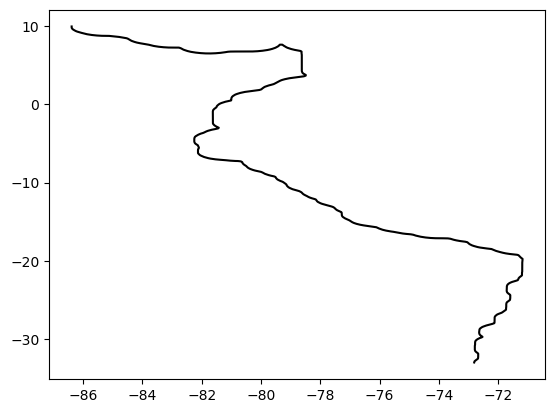

In [69]:
plt.plot(lonb1[indxlon],latb1[indxlon],color='black')

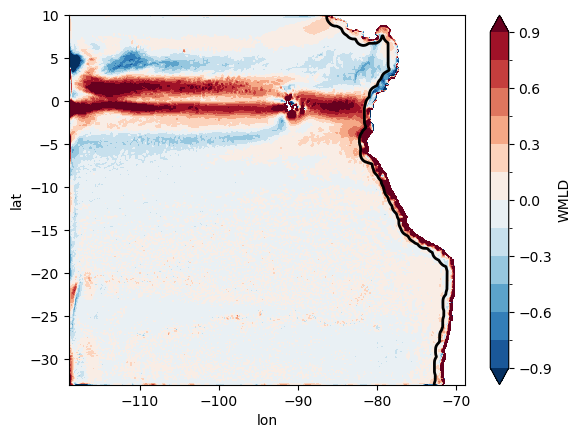

In [77]:
(mean_WMLD*86400).plot.contourf(robust=True,levels=13)
plt.plot(lonb1[indxlon],latb1[indxlon],color='black',linewidth=2)

In [153]:
mean_WMLD = WMLD_ds_.WMLD.mean(dim='time',skipna=True)
mean_WMLD = xr.where(mean_WMLD == 0, np.nan, mean_WMLD)

lat = mean_WMLD.lat.values
lon = mean_WMLD.lon.values
loni, lati = np.meshgrid(lon, lat)

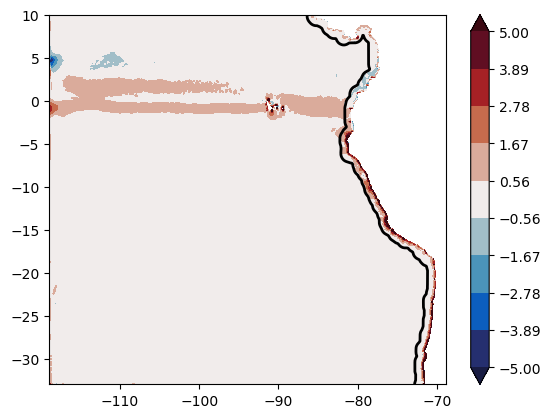

In [155]:
levels = np.linspace(-5, 5, 10)
vmin, vmax = levels.min(), levels.max()
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

plt.contourf(loni, lati, mean_WMLD*86400, cmap=cm.balance, norm=norm, 
                 extend='both', levels=levels)
plt.plot(lonb1[indxlon],latb1[indxlon],color='black',linewidth=2)
plt.colorbar()

In [156]:
##ports
Puertos = {
       "Pisco":  [-13.69388889,  -76.22416667],
    "Callao":   [-12.0575,  -77.15305556],
    "Chimbote": [-9.076666667,  -78.61472222],
    "Paita":    [-5.078055556,  -81.10638889],
    }

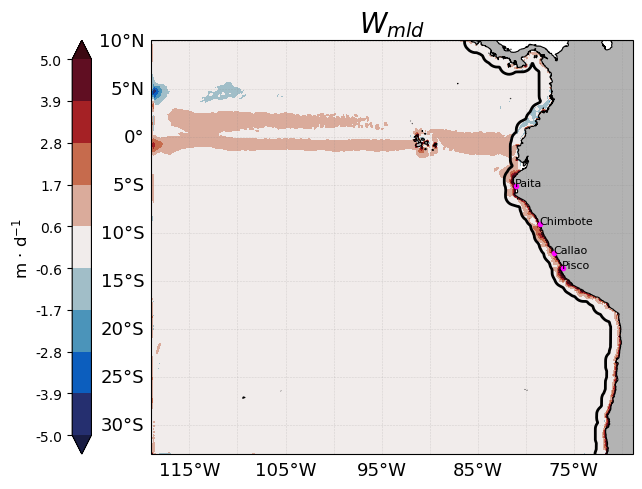

In [158]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import TwoSlopeNorm
from cmocean import cm
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.ticker import FixedLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.axes as maxes  # plain Matplotlib Axes for colorbar

# ------------------------------------------------------------------
# Inputs you already have:
# - loni, lati: 2D lon/lat arrays (same shape as mean_WMLD)
# - mean_WMLD: 2D field in m/s (we'll show m/day = *86400)
# - lonb1, latb1, indxlon: arrays for black polyline indices
# - Puertos: dict like {'PortName': (lat, lon), ...}
# ------------------------------------------------------------------

# Colormap and normalization around zero
levels = np.linspace(-5, 5, 10)
vmin, vmax = levels.min(), levels.max()
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(7.5, 5))
ax = plt.axes(projection=proj)

# Set map extent to the data bounds
ax.set_extent([np.nanmin(loni), np.nanmax(loni),
               np.nanmin(lati), np.nanmax(lati)], crs=proj)

# Filled contours (convert from m/s to m/day)
cf = ax.contourf(
    loni, lati, mean_WMLD * 86400.0,
    levels=levels, cmap=cm.balance, norm=norm, extend='both',
    transform=proj
)

# Coastlines and land shading
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.8, zorder=3)
ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor='0.7', zorder=0)

# Gridlines with labels
gl = ax.gridlines(crs=proj, draw_labels=True,
                  linewidth=0.4, color='gray', alpha=0.25, linestyle='--')
gl.right_labels = False
gl.top_labels = False
gl.xlabel_style = {'size': 13}
gl.ylabel_style = {'size': 13}

# Optional: set fixed tick spacing aligned to extent (every 5 degrees)
lon_min, lon_max, lat_min, lat_max = ax.get_extent(crs=proj)
lon_ticks = np.arange(np.floor(lon_min/5)*5, np.ceil(lon_max/5)*5 + 0.1, 5)
lat_ticks = np.arange(np.floor(lat_min/5)*5, np.ceil(lat_max/5)*5 + 0.1, 5)
gl.xlocator = FixedLocator(lon_ticks)
gl.ylocator = FixedLocator(lat_ticks)
gl.xformatter = LongitudeFormatter(number_format='.0f', degree_symbol='°', dateline_direction_label=True)
gl.yformatter = LatitudeFormatter(number_format='.0f', degree_symbol='°')

# Black line overlay
ax.plot(lonb1[indxlon], latb1[indxlon], color='k', linewidth=2,
        transform=proj, zorder=4)

# Port labels and markers
for name, (plat, plon) in Puertos.items():
    ax.plot(plon + 0.05, plat, '.', color='magenta', transform=proj, zorder=5)
    ax.text(plon, plat, name, fontsize=8, transform=proj, zorder=5)

# LEFT-SIDE COLORBAR for Cartopy GeoAxes (avoid projection KeyError)
divider = make_axes_locatable(ax)
cax = divider.append_axes("left", size="4%", pad=0.6, axes_class=maxes.Axes)
cbar = plt.colorbar(cf, cax=cax, orientation='vertical')
cbar.set_label('m · d$^{-1}$', fontsize=12)
cbar.set_ticks(levels)
cbar.set_ticklabels([f"{v:.1f}" for v in levels])
cbar.ax.yaxis.set_ticks_position('left')
cbar.ax.yaxis.set_label_position('left')

# Title
ax.set_title('$W_{mld}$', fontsize=20)

plt.tight_layout()
# plt.savefig('Figures/paper/All_region_domain.png', dpi=300, bbox_inches='tight')
plt.show()

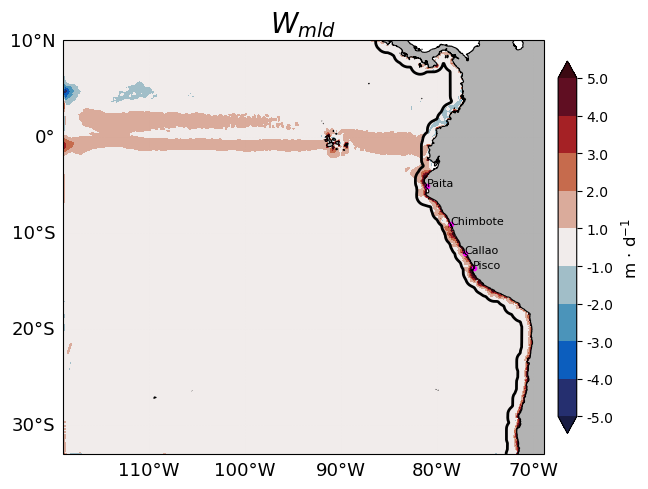

In [125]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import TwoSlopeNorm
from cmocean import cm
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.ticker import FixedLocator

levels = np.linspace(-5, 5, 10)
vmin, vmax = levels.min(), levels.max()
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(7.5, 5))
ax = plt.axes(projection=proj)

# Set extent if desired (min_lon, max_lon, min_lat, max_lat)
ax.set_extent([np.nanmin(loni), np.nanmax(loni), np.nanmin(lati), np.nanmax(lati)], crs=proj)

# Filled contours
cf = ax.contourf(
    loni, lati, mean_WMLD * 86400,
    levels=levels, cmap=cm.balance, norm=norm, extend='both',
    transform=proj
)

# Coastlines and land
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.8, zorder=3)
ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor='0.7', zorder=0)

# Optional borders
# ax.add_feature(cfeature.BORDERS.with_scale('10m'), linewidth=0.5, alpha=0.5)

# Gridlines with labels
gl = ax.gridlines(crs=proj, draw_labels=True, linewidth=0.4, color='gray', alpha=0.01, linestyle='--')
gl.right_labels = False
gl.top_labels = False
gl.xlabel_style = {'size': 13}
gl.ylabel_style = {'size': 13}

# gl = ax.gridlines(crs=proj, draw_labels=True,
#                   linewidth=0.4, color='gray', alpha=0.3, linestyle='--')

# # Turn off top/right labels to avoid overlap
# gl.right_labels = False
# gl.top_labels = False

# # Choose tick locations at 5° intervals within the current extent
# lon_min, lon_max, lat_min, lat_max = ax.get_extent(crs=proj)
# # Round to nearest 5 to stay aligned
# lon_ticks = np.arange(np.floor(lon_min/5)*5, np.ceil(lon_max/5)*5 + 0.1, 5)
# lat_ticks = np.arange(np.floor(lat_min/5)*5, np.ceil(lat_max/5)*5 + 0.1, 5)

# gl.xlocator = FixedLocator(lon_ticks)
# gl.ylocator = FixedLocator(lat_ticks)

# # Format as lon/lat with degree symbols
# gl.xformatter = LongitudeFormatter(number_format='.0f', degree_symbol='°', dateline_direction_label=True)
# gl.yformatter = LatitudeFormatter(number_format='.0f', degree_symbol='°')

# gl.xlabel_style = {'size': 10}
# gl.ylabel_style = {'size': 10}

# Black line
ax.plot(lonb1[indxlon], latb1[indxlon], color='k', linewidth=2, transform=proj, zorder=4)

# Colorbar
cbar = plt.colorbar(cf, ax=ax, orientation='vertical', pad=0.02, shrink=0.9)
cbar.set_label('m $\cdot$ d$^{-1}$', fontsize=12)
cbar.set_ticks(levels)
cbar.set_ticklabels([f"{v:.1f}" for v in np.round(levels)])

for key in Puertos:
    x, y = Puertos[key][1], Puertos[key][0]
    ax.text(x, y, key, fontsize=8)
    ax.plot(x+0.05,y, '.',color='magenta')
    
ax.set_title('$W_{mld}$', fontsize=20)
plt.tight_layout()
# plt.savefig('Figures/paper/All_region_domain.png', dpi=300, bbox_inches='tight')
plt.show()

In [159]:
mean_WMLD = WMLD_ds_.WMLD.sel(lon=slice(-84.1,-71.9),lat=slice(-16,-4.9)).mean(dim='time',skipna=True)
mean_WMLD = xr.where(mean_WMLD == 0, np.nan, mean_WMLD)

lat = mean_WMLD.lat.values
lon = mean_WMLD.lon.values
loni, lati = np.meshgrid(lon, lat)

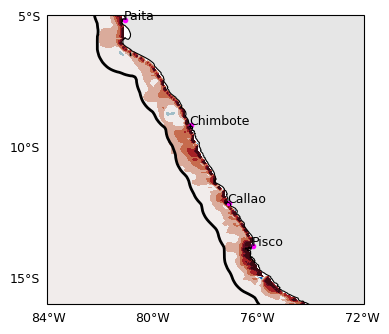

In [163]:
levels = np.linspace(-5, 5, 10)
vmin, vmax = levels.min(), levels.max()
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(4, 5))
ax = plt.axes(projection=proj)

# Set extent if desired (min_lon, max_lon, min_lat, max_lat)
ax.set_extent([np.nanmin(loni), np.nanmax(loni), np.nanmin(lati), np.nanmax(lati)], crs=proj)

# Filled contours
cf = ax.contourf(
    loni, lati, mean_WMLD * 86400,
    levels=levels, cmap=cm.balance, norm=norm, extend='both',
    transform=proj
)

# Coastlines and land
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.8, zorder=3)
ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor='0.9', zorder=0)

# Optional borders
# ax.add_feature(cfeature.BORDERS.with_scale('10m'), linewidth=0.5, alpha=0.5)

# Gridlines with labels
# gl = ax.gridlines(crs=proj, draw_labels=True, linewidth=0.4, color='gray', alpha=0.01, linestyle='--')
# gl.right_labels = False
# gl.top_labels = False
# gl.xlabel_style = {'size': 10}
# gl.ylabel_style = {'size': 10}

gl = ax.gridlines(crs=proj, draw_labels=True,
                  linewidth=0.0, color='gray', alpha=0.3, linestyle='--')

# Turn off top/right labels to avoid overlap
gl.right_labels = False
gl.top_labels = False

# Choose tick locations at 5° intervals within the current extent
lon_min, lon_max, lat_min, lat_max = ax.get_extent(crs=proj)
# Round to nearest 5 to stay aligned
lon_ticks = np.arange(np.floor(lon_min/4)*4, np.ceil(lon_max/4)*4 + 0.1,4)
lat_ticks = np.arange(np.floor(lat_min/5)*5, np.ceil(lat_max/5)*5 + 0.1, 5)

gl.xlocator = FixedLocator(lon_ticks)
gl.ylocator = FixedLocator(lat_ticks)

# Format as lon/lat with degree symbols
gl.xformatter = LongitudeFormatter(number_format='.0f', degree_symbol='°', dateline_direction_label=True)
gl.yformatter = LatitudeFormatter(number_format='.0f', degree_symbol='°')

gl.xlabel_style = {'size': 9}
gl.ylabel_style = {'size': 9}

# Black line
ax.plot(lonb1[indxlon], latb1[indxlon], color='k', linewidth=2, transform=proj, zorder=4)

# Colorbar
# cbar = plt.colorbar(cf, ax=ax, orientation='vertical', pad=0.02, shrink=0.9)
# cbar.set_label('m $\cdot$ d$^{-1}$', fontsize=12)
# cbar.set_ticks(levels)
# cbar.set_ticklabels([f"{v:.1f}" for v in np.round(levels)])

for key in Puertos:
    x, y = Puertos[key][1], Puertos[key][0]
    ax.text(x, y, key, fontsize=9)
    ax.plot(x+0.05,y-0.05, '.',color='magenta')
    
# ax.set_title('$W_{mld}$', fontsize=20)
plt.tight_layout()
# plt.savefig('Figures/paper/All_region_domain_2_x.png', dpi=300, bbox_inches='tight')
plt.show()